<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
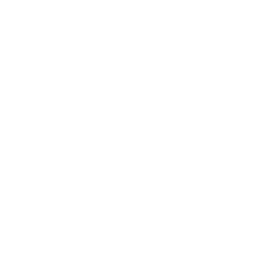
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Profilage des Montants de Transactions Bancaires</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Banque de Détail / Analyse Clientèle &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Synthèse

Cet exemple profile les montants de transactions bancaires de détail avec PROC MEANS. Il utilise le traitement de classification multivoie (`WAYS 1 2`) pour produire les résumés à une et deux voies de `TXN_AMOUNT` selon le canal et le segment client en une seule passe, le traitement BY-group découpant chaque profil par région. Une seconde étape PROC MEANS dérive les percentiles de queue supérieure (P95, P99) par région et canal comme seuils candidats pour l'alerte anti-blanchiment. Le récit ci-dessous s'appuie entièrement sur les valeurs que la procédure a réellement produites sur ce registre de 100 transactions.

## Sources de Données

| Source | Description | Enregistrements |
|--------|-------------|--------|
| WORK.BANK_TRANSACTIONS | Registre synthétique de transactions bancaires de détail avec région, canal et segment client | 100 |

---

In [1]:
/* --------------------------------------------------------
   Génère un registre synthétique de transactions bancaires de
   détail. Cet exemple s'exécute en mode sans licence, qui
   plafonne la sortie à 100 observations ; nous dimensionnons
   donc le registre à exactement 100 transactions et gardons la
   grille de classification compacte (2 régions x 3 canaux x 3
   segments). Cela garantit que chaque cellule multivoie reste
   suffisamment peuplée pour que les moyennes, écarts-types et
   percentiles soient informatifs.
   -------------------------------------------------------- */
DONNÉES work.bank_transactions;
    APPELER streaminit(42);
    LONGUEUR region $12 channel $10 segment $10;
    FAIRE txn_id = 1 JUSQU_À 100;
        region_idx = int(rand('uniform') * 2) + 1;
        SI region_idx = 1 ALORS region = 'NORD-EST';
        SINON region = 'OUEST';

        channel_idx = int(rand('uniform') * 3) + 1;
        SI channel_idx = 1 ALORS channel = 'AGENCE';
        SINON SI channel_idx = 2 ALORS channel = 'EN LIGNE';
        SINON channel = 'VIREMENT';

        segment_idx = int(rand('uniform') * 3) + 1;
        SI segment_idx = 1 ALORS segment = 'STANDARD';
        SINON SI segment_idx = 2 ALORS segment = 'AISÉ';
        SINON segment = 'PREMIUM';

        /* Le montant varie selon le palier de valeur du segment client */
        SI segment = 'PREMIUM' ALORS
            txn_amount = round(rand('exponential') * 4000 + 100, 0.01);
        SINON SI segment = 'AISÉ' ALORS
            txn_amount = round(rand('exponential') * 1500 + 50, 0.01);
        SINON
            txn_amount = round(rand('exponential') * 500 + 10, 0.01);
        /* Les virements portent des montants nettement plus importants */
        SI channel = 'VIREMENT' ALORS
            txn_amount = txn_amount * 3;
        txn_date = '01JAN2026'd + int(rand('uniform') * 90);
        account_id = cat('ACCT-', put(int(rand('uniform') * 5000) + 1, z6.));
        SORTIE;
    FIN;
    format txn_date date9. txn_amount dollar12.2;
EXÉCUTER;


NOTE: DATA work.bank_transactions


NOTE: Wrote work.bank_transactions (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


---

In [2]:
/* --------------------------------------------------------
   Volume de transactions de base par région et canal
   -------------------------------------------------------- */
proc sql;
    SÉLECTIONNER region, channel,
           count(*) COMME n_txns ÉTIQUETTE="Nb Transactions",
           sum(txn_amount) COMME total_amount format=dollar14.2 ÉTIQUETTE="Montant Total"
    DEPUIS work.bank_transactions
    GROUPE PAR region, channel
    ORDRE PAR region, channel;
QUIT;

  region   channel  Nb Transactions  Montant Total
--------  --------  ---------------  -------------
NORD-EST    AGENCE               20     $44,287.32
NORD-EST  EN LIGNE               19     $60,649.49
NORD-EST  VIREMENT               14     $65,506.08
   OUEST    AGENCE                9     $23,436.62
   OUEST  EN LIGNE               24     $43,677.03
   OUEST  VIREMENT               14     $75,894.42



NOTE: PROC SQL 

NOTE: PROC SQL statement used.


---


NOTE: PROC SGPLOT data=work.bank_transactions

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


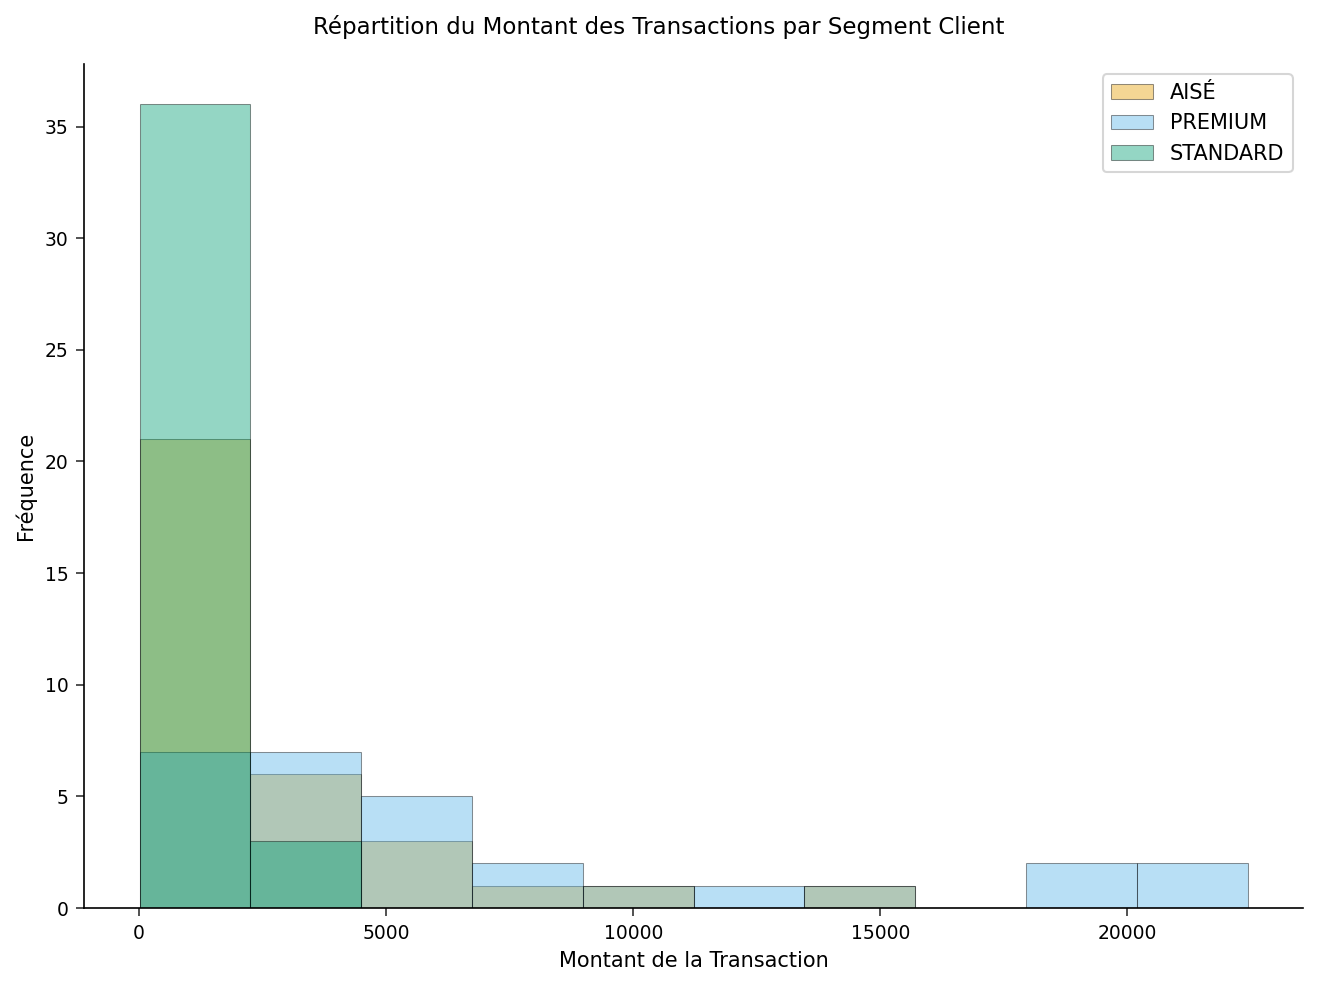

In [3]:
/* --------------------------------------------------------
   Répartition des montants de transaction par segment client
   -------------------------------------------------------- */
proc sgplot data=work.bank_transactions;
    HISTOGRAM txn_amount / group=segment TRANSPARENCY=0.4;
    XAXIS ÉTIQUETTE="Montant de la Transaction";
    YAXIS ÉTIQUETTE="Fréquence";
    TITRE "Répartition du Montant des Transactions par Segment Client";
EXÉCUTER;

---

In [4]:
/* --------------------------------------------------------
   Tri par région pour le traitement BY-group
   -------------------------------------------------------- */
proc sort data=work.bank_transactions;
    PAR region;
EXÉCUTER;


NOTE: PROC SORT data=work.bank_transactions

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.bank_transactions.
NOTE: Wrote work.bank_transactions (100 rows, 10 columns).
NOTE: PROC SORT statement used.


In [5]:
/* --------------------------------------------------------
   Profilage multivoie. WAYS 1 2 génère chaque combinaison à une
   et deux voies des variables de classification en une seule
   passe ; BY region produit un profil distinct par région.
   AUTONAME ajoute chaque statistique en suffixe au nom de la
   variable d'analyse.
   -------------------------------------------------------- */
proc means data=work.bank_transactions n mean std MIN MAX q1 q3 MEDIAN;
    PAR region;
    CLASSE channel segment;
    WAYS 1 2;
    VAR txn_amount;
    ÉTIQUETTE region = "Région"
          channel = "Canal"
          segment = "Segment Client"
          txn_amount = "Montant de la Transaction";
    SORTIE out=work.txn_profile
        n= mean= std= MIN= MAX= MEDIAN= q1= q3= / autoname;
EXÉCUTER;

--------------------------------------------------- Région=NORD-EST ---------------------------------------------------

                                                  The MEANS Procedure

                                Analysis Variable : txn_amount Montant de la Transaction

        Canal     Segment Client          N Obs           Mean        Std Dev        Minimum        Maximum  Lower Quartile  Upper Quartile         Median
        --------------------------------------------------------------------------------------------------------------------------------------------------
        AGENCE    AISÉ                        8      $1,388.74      $1,372.34         $62.41      $4,436.40         $383.19       $1,559.97      $1,362.38
        AGENCE    PREMIUM                     6      $4,869.12      $5,000.76        $527.45     $13,443.41       $1,117.08       $7,909.72      $3,108.52
        AGENCE    STANDARD                    6        $660.46        $401.58        $113.46      


NOTE: PROC MEANS
NOTE: Output dataset work.txn_profile has 30 observations and 13 variables.
NOTE: PROC MEANS statement used.


In [6]:
/* --------------------------------------------------------
   Extrait le résumé à une voie par canal (_TYPE_ = 2, où seul
   CHANNEL est actif) pour une vue de tableau de bord par canal.
   -------------------------------------------------------- */
proc sql;
    SÉLECTIONNER region, channel,
           txn_amount_n COMME n_transactions ÉTIQUETTE="Nb Transactions",
           txn_amount_mean COMME avg_amount format=dollar12.2 ÉTIQUETTE="Montant Moyen",
           txn_amount_median COMME median_amount format=dollar12.2 ÉTIQUETTE="Montant Médian",
           txn_amount_stddev COMME std_amount format=dollar12.2 ÉTIQUETTE="Écart-Type du Montant"
    DEPUIS work.txn_profile
    OÙ _type_ = 2
    ORDRE PAR region, channel;
QUIT;

  region   channel  Nb Transactions  Montant Moyen   Montant Médian   Écart-Type du Montant
--------  --------  ---------------  -------------  ---------------  ----------------------
NORD-EST    AGENCE             20.0      $2,214.37        $1,065.89               $3,254.59
NORD-EST  EN LIGNE             19.0      $3,192.08        $1,451.42               $4,749.86
NORD-EST  VIREMENT             14.0      $4,679.01        $2,415.73               $5,593.67
   OUEST    AGENCE              9.0      $2,604.07        $3,019.18               $2,308.55
   OUEST  EN LIGNE             24.0      $1,819.88          $363.46               $4,602.84
   OUEST  VIREMENT             14.0      $5,421.03        $2,985.11               $6,046.75



NOTE: PROC SQL 

NOTE: PROC SQL statement used.


In [7]:
/* --------------------------------------------------------
   Seuils de la queue supérieure : P95, P99 et le maximum par
   région et canal. En production, ces estimations de queue
   alimentent le calibrage des alertes anti-blanchiment. Sur un
   registre de 100 lignes, les effectifs par cellule sont
   faibles, donc les percentiles sont illustratifs plutôt que
   calibrés.
   -------------------------------------------------------- */
proc means data=work.bank_transactions p95 p99 MAX;
    PAR region;
    CLASSE channel;
    VAR txn_amount;
    ÉTIQUETTE region = "Région"
          channel = "Canal"
          txn_amount = "Montant de la Transaction";
    SORTIE out=work.aml_thresholds
        p95= p99= MAX= / autoname;
EXÉCUTER;

--------------------------------------------------- Région=NORD-EST ---------------------------------------------------

                                                  The MEANS Procedure

                               Analysis Variable : txn_amount Montant de la Transaction

                                          N
                            Canal       Obs       95th Pctl       99th Pctl         Maximum
                            ---------------------------------------------------------------
                            AGENCE       20      $10,676.57      $13,443.41      $13,443.41
                            EN LIGNE     19      $18,941.55      $18,941.55      $18,941.55
                            VIREMENT     14      $18,534.36      $18,534.36      $18,534.36
                            ---------------------------------------------------------------


---------------------------------------------------- Région=OUEST -----------------------------------------------------




NOTE: PROC MEANS
NOTE: Output dataset work.aml_thresholds has 8 observations and 7 variables.
NOTE: PROC MEANS statement used.


---

### Interprétation

Le profil multivoie confirme que le segment client et le canal déterminent conjointement la taille des transactions. Au sein des cellules à deux voies (canal x segment), les clients du segment PREMIUM affichent les montants moyens les plus élevés dans chaque canal où ils apparaissent : dans l'Ouest, les transactions PREMIUM en ligne atteignent une moyenne de 8 879,75 \$ (n=4, max 22 431,64 \$) et les transactions PREMIUM par virement atteignent une moyenne de 11 119,84 \$ (n=4, max 21 880,47 \$), contre 289,91 \$ pour le segment STANDARD en ligne dans l'Ouest et 443,53 \$ pour le segment STANDARD en agence dans l'Ouest. Dans le Nord-Est, le segment PREMIUM en ligne affiche une moyenne de 5 676,90 \$ sur 10 transactions, tandis que le segment STANDARD en ligne affiche une moyenne de 427,08 \$ — un écart d'un ordre de grandeur qui fait du segment PREMIUM le principal facteur prédictif de la valeur des transactions.

L'étape des percentiles illustre comment PROC MEANS alimente le calibrage des seuils. Sur ce registre de 100 lignes, les effectifs par cellule sont faibles, donc les estimations P95/P99 se situent près du maximum de chaque cellule : le canal en ligne dans l'Ouest culmine à un P99 de 22 431,64 \$ et le virement dans l'Ouest à 21 880,47 \$, tandis que le canal en ligne dans le Nord-Est atteint 18 941,55 \$. La cellule à observation unique du virement PREMIUM dans le Nord-Est (18 534,36 \$, écart-type manquant) rappelle que les cellules peu peuplées produisent des estimations de queue instables — en production, ces seuils seraient recalculés sur le registre complet, mais la mécanique de la procédure présentée ici est exactement ce qu'un analyste exécuterait. L'histogramme ci-dessus montre la distribution des montants asymétrique à droite attendue, le segment PREMIUM s'étendant le plus loin dans la queue supérieure.

---

In [8]:
/* --------------------------------------------------------
   Exporte les tables de profilage et de seuils AML
   -------------------------------------------------------- */
proc export data=work.txn_profile
    OUTFILE='transaction_profiles.csv'
    DBMS=csv REMPLACER;
EXÉCUTER;

proc export data=work.aml_thresholds
    OUTFILE='aml_thresholds_by_region.csv'
    DBMS=csv REMPLACER;
EXÉCUTER;


NOTE: PROC EXPORT data=work.txn_profile outfile=transaction_profiles.csv

NOTE: Exported 30 rows to transaction_profiles.csv.
NOTE: PROC EXPORT data=work.aml_thresholds outfile=aml_thresholds_by_region.csv

NOTE: Exported 8 rows to aml_thresholds_by_region.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidentiel
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Propulsé par <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>